# 🏆 VLM Fine-tuning
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/1bz7ZrFLCC9R4MeKmTeAvZkSKRBDa5VV4/view?usp=sharing)

> 📖 **New to VLMs?** Read the [VLM Usage notebook](https://drive.google.com/file/d/1oTRGVAbx3zY8M9Kau8xqIvxjLr1QbIsq/view?usp=sharing) first. It covers what VLMs are and how to run inference, before you fine-tune one here.

In this notebook you'll fine-tune **Qwen2.5-VL-7B-Instruct** to answer questions about images in **Moroccan Darija**, using **LoRA** (updates ~1% of the model weights, no supercomputer needed).

**What you need:** a GPU runtime (Colab T4 is fine) + a free HuggingFace account to save your model.  
⏱ **Expected total time: ~20 minutes** on a T4 GPU.


In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
    !uv pip install -qqq --no-deps "torchcodec==0.7.0"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps "tokenizers>=0.22.0,<=0.23.0" trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0
!uv pip install --no-deps --upgrade "torchao>=0.16.0"

In [2]:
# check GPU

!nvidia-smi

Sat May 16 16:54:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Authenticate with HuggingFace to save your model. Create a free account at [huggingface.co](https://huggingface.co) if you don't have one yet.

In [5]:
from google.colab import userdata
HF_TOKEN=userdata.get('HF_TOKEN')

In [7]:
from huggingface_hub import notebook_login
notebook_login()

# TODO: set your username here — used when saving the model
HF_USERNAME = "Haitam03"


## Model Architecture

Qwen2.5-VL has three components.

| Component | Role |
|---|---|
| **Vision Encoder (ViT)** | Extracts visual features from the image |
| **Projector** | Maps image features into the LLM's token space |
| **Language Model** | Generates the text answer |

<br>

> The model is already pre-trained on billions of image-text pairs. We only need **Supervised Fine-tuning** to adapt it to Darija Visual Question Answering (VQA).


## 1. Load Model
We load a **4-bit quantized** version of the model to save VRAM. Then we add **LoRA adapters** — small trainable matrices injected into the model — so we only train ~1% of parameters.

In [8]:
from unsloth import FastVisionModel
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit",
    # "unsloth/Qwen3.5-4B",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,           # LoRA rank — higher = more capacity (try 8 or 32)
    lora_alpha=16,  # Keep equal to r
    lora_dropout=0,
    bias="none",
    random_state=3407,
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen2_5_Vl patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.90G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

## 2. Load & Format Dataset

We use the [Darija-VLM-Dataset](https://huggingface.co/datasets/HackAI-2025/Darija-VLM-Dataset): images with questions and answers in Moroccan Darija.
We split it 80/10/10 (train/val/test) and format each sample as a chat conversation.


README.md:   0%|          | 0.00/403 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/307M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1878 [00:00<?, ? examples/s]

Question: شنو هاد البلاصة اللي فيها هاد التصويرة و شنو كيديرو فيها؟
Answer:   هادي سميتها الدباغة، كاينة فمدينة فاس. هنا فين كيصبغو الجلود باش يصاوبو منهم الصبابط و الشكارة و بزاف ديال الحوايج.


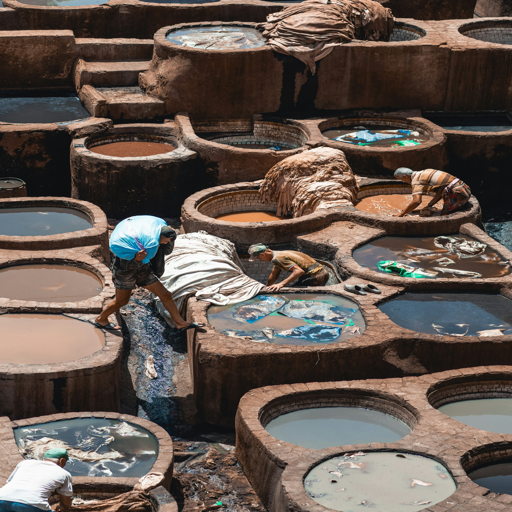

In [9]:
from datasets import load_dataset

dataset = load_dataset("HackAI-2025/darija-vlm-dataset", split="train")

# Quick look at one sample
print("Question:", dataset[2]["question"])
print("Answer:  ", dataset[2]["answer"])
dataset[2]["image"]


In [11]:
# Split: 80% train, 10% val, 10% test
train_valtest = dataset.train_test_split(test_size=0.2, seed=42, shuffle=True)
train_ds = train_valtest["train"]
valtest   = train_valtest["test"].train_test_split(test_size=0.5, seed=42)
val_ds    = valtest["train"]
test_ds   = valtest["test"]

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 1502 | Val: 188 | Test: 188


In [12]:
# Format each sample as a 3-turn chat: system → user (image + question) → assistant (answer)
system_message = """You are a Vision Language Model, designed to understand images.
Answer clearly in Moroccan Darija."""

def convert_to_conversation(sample):
    return {"messages": [
        {"role": "system",    "content": [{"type": "text",  "text": system_message}]},
        {"role": "user",      "content": [{"type": "text",  "text": sample["question"]},
                                          {"type": "image", "image": sample["image"]}]},
        {"role": "assistant", "content": [{"type": "text",  "text": sample["answer"]}]},
    ]}

train_dataset = [convert_to_conversation(s) for s in train_ds]
val_dataset   = [convert_to_conversation(s) for s in val_ds]
test_dataset  = [convert_to_conversation(s) for s in test_ds]


## 3. Fine-tune

We use **Supervised Fine-Tuning (SFT)**: show the model (image, question) pairs and train it to produce the correct Darija answer for new image, question pairs.

Key parameters to experiment with:
- `max_steps` — more steps = better quality, longer training
- `learning_rate` — lower if loss is unstable
- `r` in LoRA — higher rank = more expressivity


In [13]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=SFTConfig(
        output_dir="Qwen2-VL-7B-Instruct-Darija-VQA",
        # output_dir=f"Qwen3_5_VQA_Darija",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=2,
        warmup_steps=5,
        # max_steps=50,                    # ← increase for better results
        num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate=2e-4,
        # fp16=not is_bf16_supported(),
        bf16=is_bf16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        report_to="none",                # change to "wandb" if you use W&B (Weighs & Biases or Trackio)
        push_to_hub=True,
        hub_model_id=f"{HF_USERNAME}/Qwen2-VL-7B-Instruct-Darija-VQA",
        hub_strategy="all_checkpoints",

        # Required for vision fine-tuning:
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        dataset_num_proc=4,
        max_seq_length=2048,
    ),
)


Unsloth: Model does not have a default image size - using 512


In [14]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,502 | Num Epochs = 1 | Total steps = 376
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 51,521,536 of 8,343,688,192 (0.62% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,5.773872
20,2.395742
30,1.786115
40,1.683456


KeyboardInterrupt: 

## 4. Save the Model
This saves only the LoRA adapters (~ MB), not the full 7B model.

In [15]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

model.push_to_hub(f"{HF_USERNAME}/lora_model")
tokenizer.push_to_hub(f"{HF_USERNAME}/lora_model")


Unsloth: Restored added_tokens_decoder metadata in lora_model/tokenizer_config.json.


README.md:   0%|          | 0.00/578 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 54.9kB /  206MB            

Saved model to https://huggingface.co/Haitam03/lora_model


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmps49z9clo/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mps49z9clo/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

## 5. Evaluate: Before vs After Fine-tuning

Let's compare how the model answers **before** training vs **after** loading our fine-tuned adapters.


In [16]:
def inference(mdl, tok, messages, image):
    FastVisionModel.for_inference(mdl)
    input_text = tok.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tok(image, input_text, add_special_tokens=False, return_tensors="pt").to("cuda")
    from transformers import TextStreamer
    streamer = TextStreamer(tok, skip_prompt=True)
    mdl.generate(**inputs, streamer=streamer, max_new_tokens=128, use_cache=True,
                 temperature=1.5, min_p=0.1)


In [17]:
# Pick a test sample
test_index = 34
messages    = test_dataset[test_index]["messages"][0:2]
image       = messages[1]["content"][1]["image"]
question    = messages[1]["content"][0]["text"]
ground_truth = test_dataset[test_index]["messages"][2]["content"][0]["text"]

print("Question:       ", question)
print("Expected answer:", ground_truth)
print("\n--- Base model answer (before fine-tuning) ---")
inference(model, tokenizer, messages, image)


Question:         شنو كنشوفو ف هاد التصويرة، واش شي بناية ولا شنو؟
Expected answer: كنشوفو جزء من شي بناية كبيرة، يمكن تكون شركة ولا مكتب، و عندها واحد الديكور بحال الشبكة على برا.

--- Base model answer (before fine-tuning) ---
كنشوفوا ف هاد التصويرة هاد الستين ريزا، واش كمان كيتستخدم ديال الصناعة في بحال واحد ف المعمارية. كما كنشوفو لونها، و كيدل على التكنولوجيا.<|im_end|>


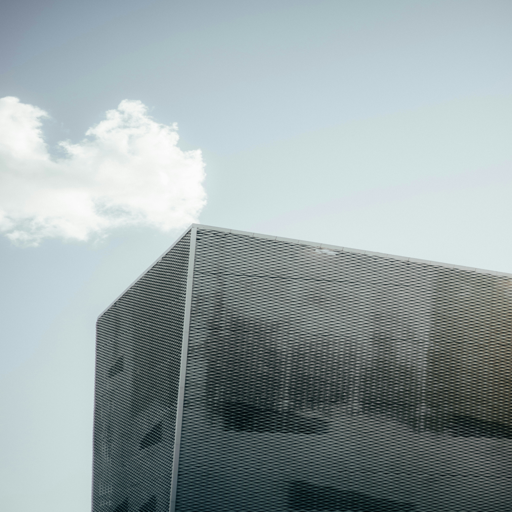

In [18]:
image

In [19]:
# Load the fine-tuned model
from unsloth import FastVisionModel

finetuned_model, tokenizer = FastVisionModel.from_pretrained(
    model_name="lora_model",
    load_in_4bit=True,
)
FastVisionModel.for_inference(finetuned_model)

print("Question:       ", question)
print("Expected answer:", ground_truth)
print("\n--- Fine-tuned model answer ---")
inference(finetuned_model, tokenizer, messages, image)


==((====))==  Unsloth 2026.5.2: Fast Qwen2_5_Vl patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Question:         شنو كنشوفو ف هاد التصويرة، واش شي بناية ولا شنو؟
Expected answer: كنشوفو جزء من شي بناية كبيرة، يمكن تكون شركة ولا مكتب، و عندها واحد الديكور بحال الشبكة على برا.

--- Fine-tuned model answer ---
كنشوفو داير ف هادي التصويرة، بناية لابسين لباس كيرفل واش كاين نصب بحال مهتضر، ولا هادي حدا ليا ولا زوج لبصرين، كاين كيلاب ديال الرئيسيات واش كيعني ف هادي المكان كيكون واحد كبار.<|im_end|>


**Did you notice the difference in the VLM performance??**

**Good luck with the rest of the challenge—and HAVE FUN! 🚀**
___